In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Cell 2: Load dataset
df = pd.read_csv('../data/spam.csv',
            sep = '\t',
            header = None,
            names = ['label','message'])
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head() 

Dataset shape: (5612, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5612 entries, 0 to 5611
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5612 non-null   object
 1   message  5612 non-null   object
dtypes: object(2)
memory usage: 87.8+ KB
None

Label Distribution (Raw Counts):
label
ham     4825
spam     787
Name: count, dtype: int64

Label Distribution (Percentage):
label
ham     85.976479
spam    14.023521
Name: proportion, dtype: float64


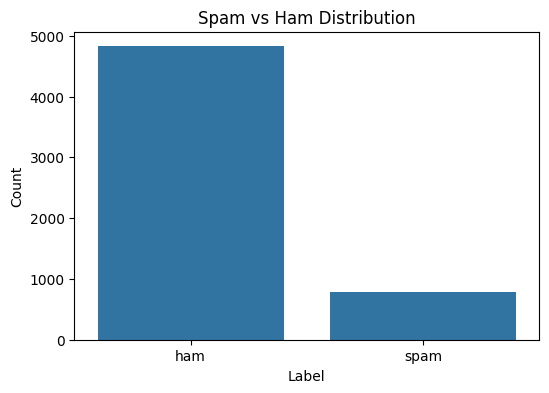

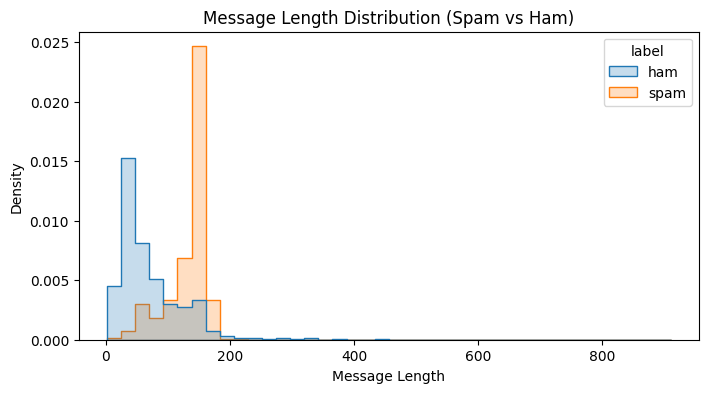


Average Message Length:
Ham : 71.48
Spam: 134.89

Median Message Length:
Ham : 52.00
Spam: 148.00


In [3]:
# Cell 3: Exploratory Data Analysis (EDA)

print("Dataset Info:")
print(df.info())

print("\nLabel Distribution (Raw Counts):")
print(df['label'].value_counts())

print("\nLabel Distribution (Percentage):")
print(df['label'].value_counts(normalize=True) * 100)

# Convert label early (important for consistency checks)
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Visualize label distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Message length feature
df['message_length'] = df['message'].apply(len)

# Compare distributions
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=40,
    element='step',
    stat='density',
    common_norm=False
)
plt.title('Message Length Distribution (Spam vs Ham)')
plt.xlabel('Message Length')
plt.ylabel('Density')
plt.show()

# Summary stats
print("\nAverage Message Length:")
print(f"Ham : {df[df['label']=='ham']['message_length'].mean():.2f}")
print(f"Spam: {df[df['label']=='spam']['message_length'].mean():.2f}")

print("\nMedian Message Length:")
print(f"Ham : {df[df['label']=='ham']['message_length'].median():.2f}")
print(f"Spam: {df[df['label']=='spam']['message_length'].median():.2f}")

In [ ]:
# Cell 4: Text Preprocessing Function 

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clean_text(text):
    """
    Clean and preprocess text message (optimized for ML accuracy)
    """

    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation (keep structure simple)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 3. DO NOT remove numbers completely (important for spam detection)
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Tokenization
    tokens = text.split()

    # 5. Remove stopwords + stemming (light preprocessing only)
    tokens = [
        ps.stem(word)
        for word in tokens
        if word not in stop_words
    ]

    return ' '.join(tokens)


# Apply preprocessing
df['clean_message'] = df['message'].apply(clean_text)

print("Sample after preprocessing:")
print(f"Original: {df['message'].iloc[0]}")
print(f"Cleaned: {df['clean_message'].iloc[0]}")

Sample after preprocessing:
Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned: go jurong point crazi avail bugi n great world la e buffet cine got amor wat


In [ ]:
# Cell 5: Feature Extraction (TF-IDF )

# Use existing label encoding 
if 'label_encoded' not in df.columns:
    df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'],
    df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# TF-IDF Vectorization (OPTIMIZED)
tfidf = TfidfVectorizer(
    max_features=20000,      # increased for better coverage
    ngram_range=(1, 2),      # BEST for spam detection
    min_df=2,
    max_df=0.85,             # removes extremely common noise words
    sublinear_tf=True        # improves scaling
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF Matrix shape - Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}")

Training set size: 4489
Test set size: 1123

TF-IDF Matrix shape - Train: (4489, 7719), Test: (1123, 7719)


In [ ]:
# Cell 6: Train Models 



models = {
    'Naive Bayes': MultinomialNB(),

    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=3000,
        class_weight='balanced'
    ),

    
}

results = {}

best_model = None
best_score = 0

for name, model in models.items():

    # Train model
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    # Track best model
    if f1 > best_score:
        best_score = f1
        best_model = model


# Convert results to DataFrame
results_df = pd.DataFrame(results).T

print("\n\nModel Comparison:")
print(results_df)

print("\nBest Model Selected:", best_model)


Naive Bayes Results:
Accuracy: 0.9644
Precision: 1.0000
Recall: 0.7452
F1-Score: 0.8540

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.75      0.85       157

    accuracy                           0.96      1123
   macro avg       0.98      0.87      0.92      1123
weighted avg       0.97      0.96      0.96      1123


Logistic Regression Results:
Accuracy: 0.9760
Precision: 0.9012
Recall: 0.9299
F1-Score: 0.9154

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.90      0.93      0.92       157

    accuracy                           0.98      1123
   macro avg       0.94      0.96      0.95      1123
weighted avg       0.98      0.98      0.98      1123



Model Comparison:
                     accuracy  precision    recall  f1_score
Naive Bayes          0.964381  

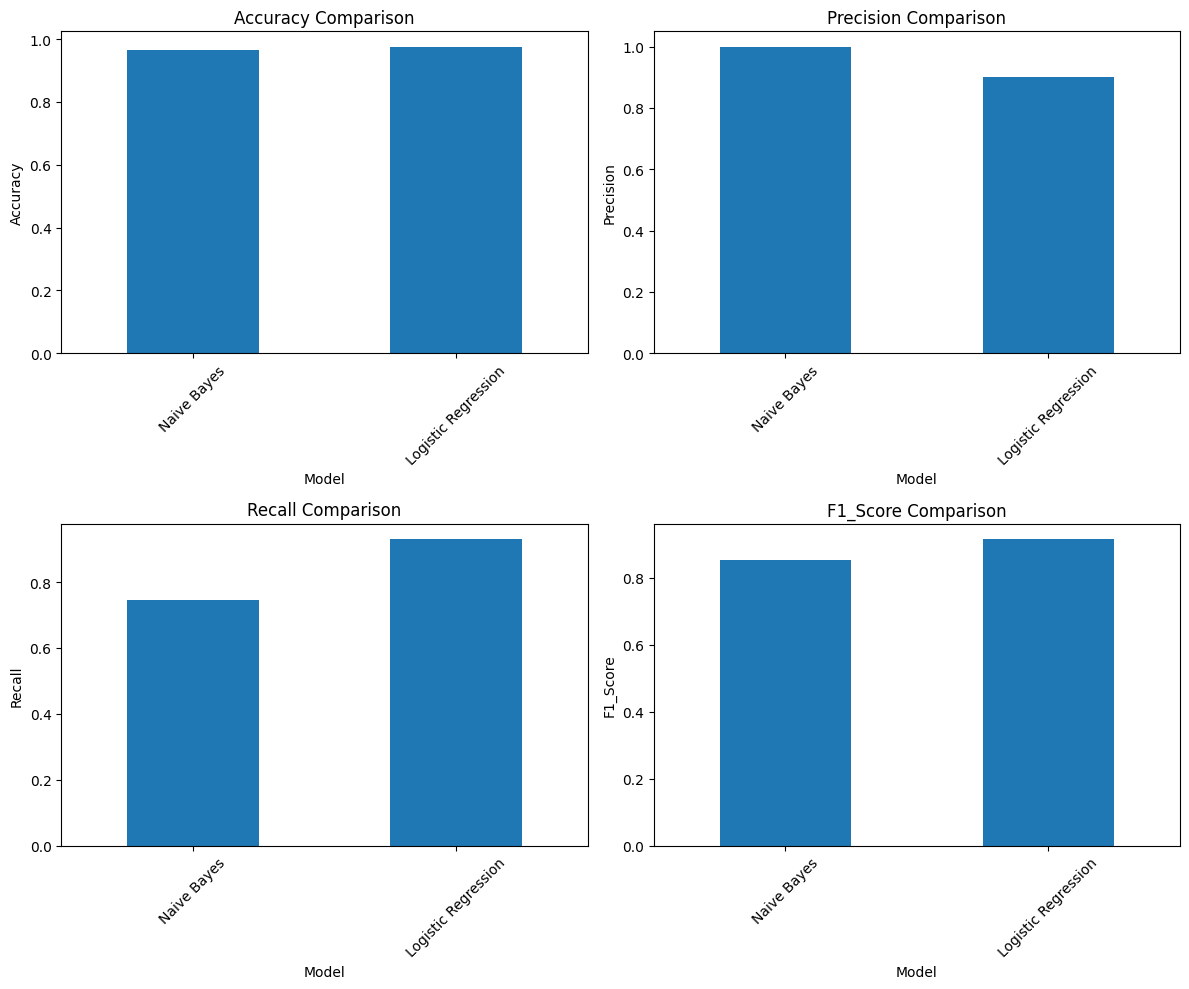

Using Best Model: LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)


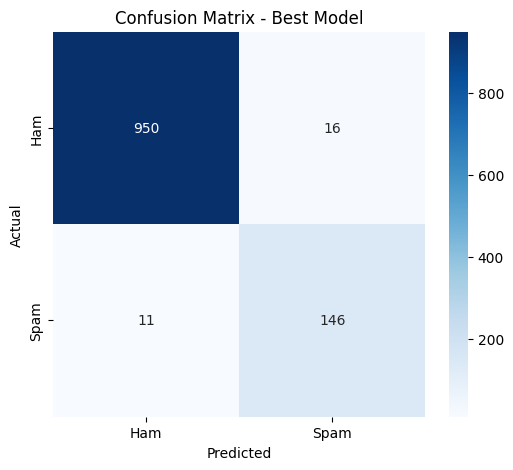


Final Model Performance:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.90      0.93      0.92       157

    accuracy                           0.98      1123
   macro avg       0.94      0.96      0.95      1123
weighted avg       0.98      0.98      0.98      1123



In [ ]:
# Cell 7: Visualize Results 

# Ensure results_df exists
results_df = pd.DataFrame(results).T

# ---- 1. Model Comparison Plots ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']

for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2

    results_df[metric].plot(kind='bar', ax=axes[row, col])
    axes[row, col].set_title(f'{metric.title()} Comparison')
    axes[row, col].set_xlabel('Model')
    axes[row, col].set_ylabel(metric.title())
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# ---- 2. Use BEST MODEL from Cell 6 (IMPORTANT FIX) ----
print("Using Best Model:", best_model)

y_pred_best = best_model.predict(X_test_tfidf)

# ---- 3. Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# ---- 4. Final Report ----
print("\nFinal Model Performance:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

In [ ]:

# Cell 8: Save Best Model and Vectorizer
import os

# Ensure models folder exists
os.makedirs('../models', exist_ok=True)

# ---- 1. Save ACTUAL BEST MODEL from Cell 6 ----
print("Saving Best Model:", best_model)

joblib.dump(best_model, '../models/spam_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")


# ---- 2. Load again (restart safety test) ----
loaded_model = joblib.load('../models/spam_model.pkl')
loaded_vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')


# ---- 3. Quick sanity test ----
test_msg = "URGENT loan offer! Get cash instantly"

cleaned = clean_text(test_msg)
vector = loaded_vectorizer.transform([cleaned])
pred = loaded_model.predict(vector)[0]

print("\nSanity Test Message:", test_msg)
print("Prediction:", "Spam" if pred == 1 else "Ham")

Saving Best Model: LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)
Model and vectorizer saved successfully!

Sanity Test Message: URGENT loan offer! Get cash instantly
Prediction: Spam


In [ ]:
# Cell 9: Prediction Function 

import numpy as np

def predict_spam(message, model, vectorizer):
    """
    Predict whether a message is Spam or Ham (ROBUST VERSION)
    """

    # 1. Clean text
    cleaned = clean_text(message)

    # 2. Transform using TF-IDF
    transformed = vectorizer.transform([cleaned])

    # 3. Prediction
    prediction = model.predict(transformed)[0]

    # 4. Handle probability safely
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(transformed)[0]
        ham_prob = prob[0]
        spam_prob = prob[1]

    else:
        # For LinearSVC (no probability support)
        decision = model.decision_function(transformed)[0]

        # Convert decision score to pseudo-probability
        spam_prob = 1 / (1 + np.exp(-decision))
        ham_prob = 1 - spam_prob

    # 5. Final label
    label = "Spam" if prediction == 1 else "Ham"
    confidence = max(ham_prob, spam_prob)

    return label, confidence, ham_prob, spam_prob


# ---- TESTING ----
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your bank account has been compromised. Verify now!",
    "The project report is attached. Please review and share feedback.",
    "Limited time loan offer. Get cash instantly with zero documents!"
]

print("Testing Predictions:\n" + "="*50)

for msg in test_messages:
    label, confidence, ham_prob, spam_prob = predict_spam(
        msg, loaded_model, loaded_vectorizer
    )

    print(f"\nMessage: {msg[:70]}...")
    print(f"Prediction: {label}")
    print(f"Ham Probability: {ham_prob:.2%}")
    print(f"Spam Probability: {spam_prob:.2%}")
    print(f"Confidence: {confidence:.2%}")
    print("-"*50)

Testing Predictions:

Message: Congratulations! You've won a free iPhone. Click here to claim now!...
Prediction: Spam
Ham Probability: 5.29%
Spam Probability: 94.71%
Confidence: 94.71%
--------------------------------------------------

Message: Hey, are we still meeting for lunch tomorrow?...
Prediction: Ham
Ham Probability: 95.13%
Spam Probability: 4.87%
Confidence: 95.13%
--------------------------------------------------

Message: URGENT: Your bank account has been compromised. Verify now!...
Prediction: Spam
Ham Probability: 14.23%
Spam Probability: 85.77%
Confidence: 85.77%
--------------------------------------------------

Message: The project report is attached. Please review and share feedback....
Prediction: Ham
Ham Probability: 72.73%
Spam Probability: 27.27%
Confidence: 72.73%
--------------------------------------------------

Message: Limited time loan offer. Get cash instantly with zero documents!...
Prediction: Spam
Ham Probability: 25.42%
Spam Probability: 74.58%
Con

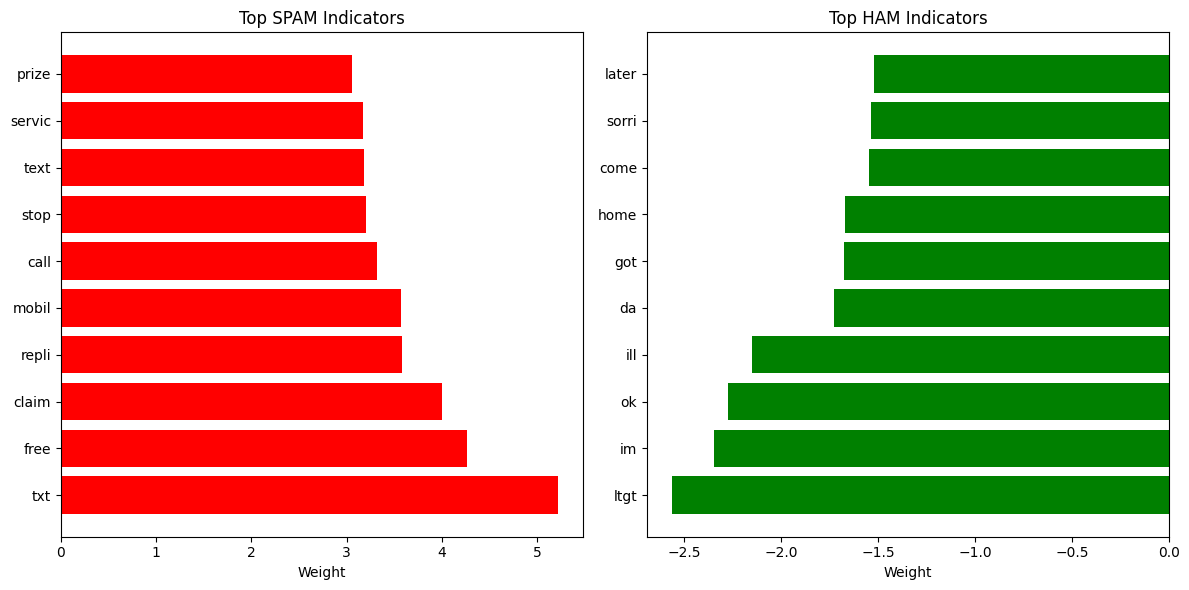

In [ ]:
# Cell 10: Feature Importance 

import numpy as np

feature_names = loaded_vectorizer.get_feature_names_out()

# Check if model supports feature importance
if hasattr(loaded_model, "coef_"):

    coefficients = loaded_model.coef_[0]

    # Top SPAM indicators (strong positive weights)
    spam_features = sorted(
        zip(feature_names, coefficients),
        key=lambda x: x[1],
        reverse=True
    )[:10]

    # Top HAM indicators (strong negative weights)
    ham_features = sorted(
        zip(feature_names, coefficients),
        key=lambda x: x[1]
    )[:10]

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    spam_words = [w for w, c in spam_features]
    spam_scores = [c for w, c in spam_features]

    ham_words = [w for w, c in ham_features]
    ham_scores = [c for w, c in ham_features]

    ax1.barh(spam_words, spam_scores, color='red')
    ax1.set_title('Top SPAM Indicators')
    ax1.set_xlabel('Weight')

    ax2.barh(ham_words, ham_scores, color='green')
    ax2.set_title('Top HAM Indicators')
    ax2.set_xlabel('Weight')

    plt.tight_layout()
    plt.show()

else:
    print("Feature importance not available for this model.")